<a href="https://colab.research.google.com/github/izual61/Telecom-Challenge-X-2/blob/main/TELECOM_CHALLENGE_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/izual61/Telecom-Challenge-X-2/refs/heads/main/TelecomX_datos_tratados.csv"

df = pd.read_csv(url)

# convertir variable objetivo
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# eliminar ID
df = df.drop("customerID", axis=1)

# convertir columnas numéricas correctamente
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
df["Charges.Monthly"] = pd.to_numeric(df["Charges.Monthly"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

# detectar columnas categóricas reales
cat_cols = df.select_dtypes(include=["object"]).columns

# aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# verificar dimensiones
print("Dimensiones finales:", df_encoded.shape)
df_encoded.head()

# exportar dataset final
df_encoded.to_csv("TelecomX_ML_ready.csv", index=False)

Dimensiones finales: (7267, 31)


Porcentaje de clientes:
Churn
0    74.280996
1    25.719004
Name: proportion, dtype: float64


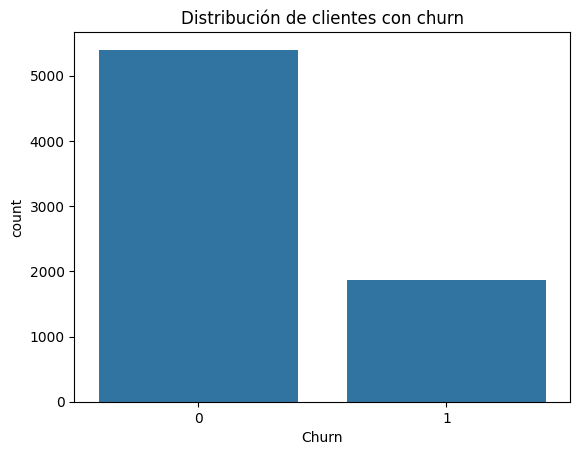

In [9]:
churn_percentage = df_encoded["Churn"].value_counts(normalize=True) * 100

print("Porcentaje de clientes:")
print(churn_percentage)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df_encoded)

plt.title("Distribución de clientes con churn")
plt.show()

In [13]:
df_encoded.isna().sum().sort_values(ascending=False)

df_encoded = df_encoded.dropna()

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [14]:
from imblearn.over_sampling import SMOTE

# ================================
# 1. Separar variables
# ================================
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# ================================
# 2. Aplicar SMOTE
# ================================
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# ================================
# 3. Verificar balance
# ================================
print("Distribución original:")
print(y.value_counts())

print("\nDistribución después de SMOTE:")
print(y_resampled.value_counts())

Distribución original:
Churn
0    5387
1    1869
Name: count, dtype: int64

Distribución después de SMOTE:
Churn
0    5387
1    5387
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler

# separar variables
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# escalar variables
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

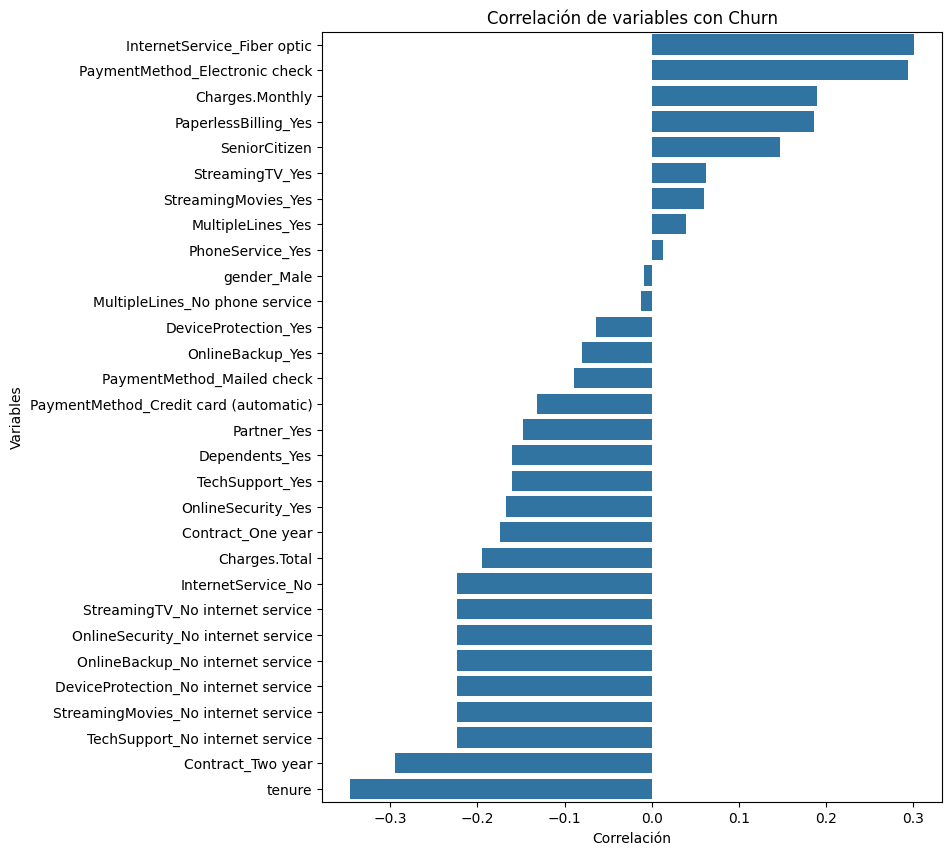

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# calcular correlación con churn
churn_corr = df_encoded.corr()["Churn"].sort_values(ascending=False)

# eliminar la autocorrelación de churn
churn_corr = churn_corr.drop("Churn")

# gráfico
plt.figure(figsize=(8,10))

sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index
)

plt.title("Correlación de variables con Churn")
plt.xlabel("Correlación")
plt.ylabel("Variables")

plt.show()

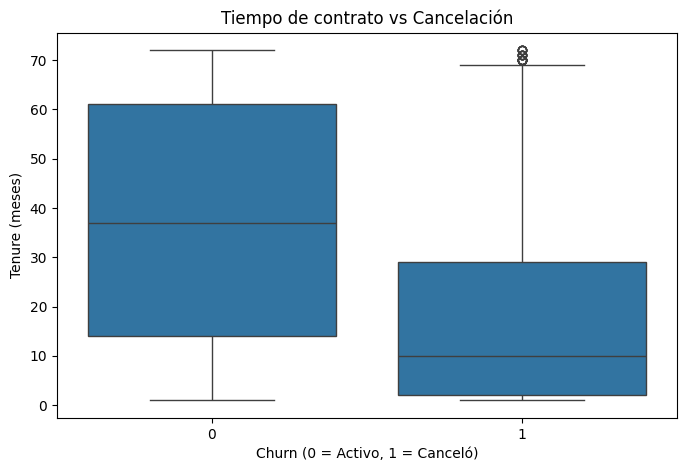

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_encoded["Churn"],
    y=df_encoded["tenure"]
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn (0 = Activo, 1 = Canceló)")
plt.ylabel("Tenure (meses)")

plt.show()


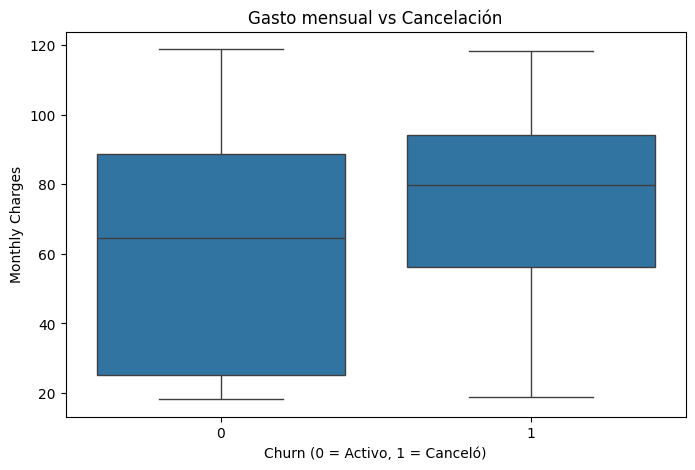

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_encoded["Churn"],
    y=df_encoded["Charges.Monthly"]
)

plt.title("Gasto mensual vs Cancelación")
plt.xlabel("Churn (0 = Activo, 1 = Canceló)")
plt.ylabel("Monthly Charges")

plt.show()

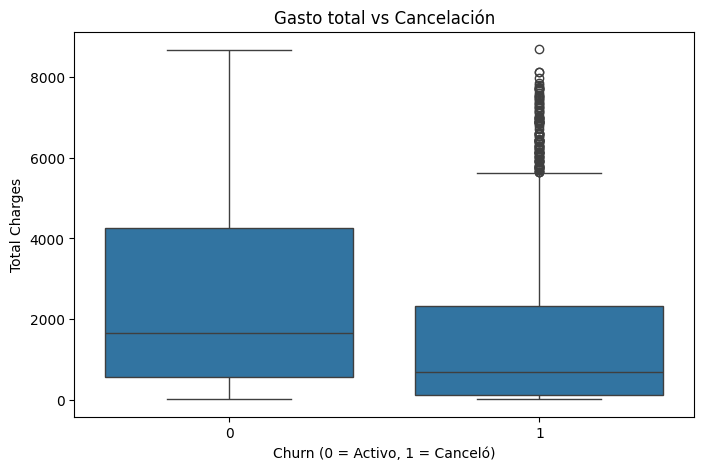

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_encoded["Churn"],
    y=df_encoded["Charges.Total"]
)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn (0 = Activo, 1 = Canceló)")
plt.ylabel("Total Charges")

plt.show()

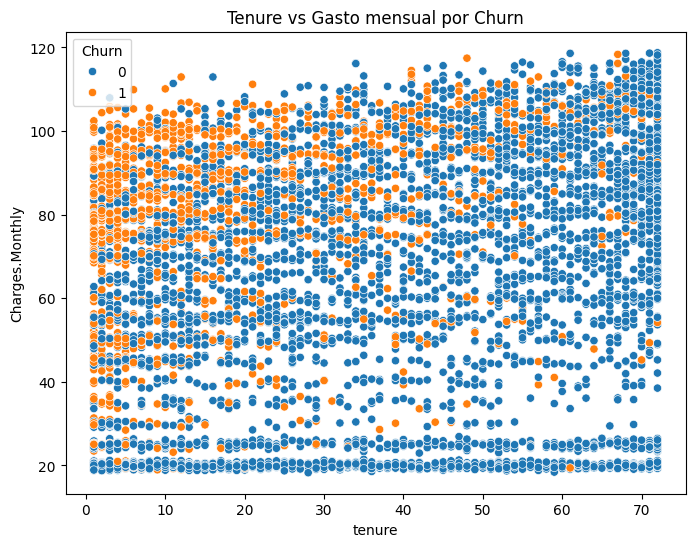

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_encoded["tenure"],
    y=df_encoded["Charges.Monthly"],
    hue=df_encoded["Churn"]
)

plt.title("Tenure vs Gasto mensual por Churn")

plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

Entrenamiento: (5079, 30)
Prueba: (2177, 30)


MODELO 1 - REGRESION LOGISTICA

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# normalizar datos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# modelo
log_model = LogisticRegression(max_iter=1000)

# entrenar
log_model.fit(X_train_scaled, y_train)

# predicciones
y_pred_log = log_model.predict(X_test_scaled)

# evaluación
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy Regresión Logística: 0.8024804777216353
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1616
           1       0.64      0.53      0.58       561

    accuracy                           0.80      2177
   macro avg       0.74      0.71      0.73      2177
weighted avg       0.79      0.80      0.80      2177



MODELO 2 RANDOM FOREST

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# entrenar
rf_model.fit(X_train, y_train)

# predicciones
y_pred_rf = rf_model.predict(X_test)

# evaluación
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy Random Forest: 0.7813504823151125
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1616
           1       0.60      0.45      0.52       561

    accuracy                           0.78      2177
   macro avg       0.71      0.67      0.69      2177
weighted avg       0.77      0.78      0.77      2177



METRICAS

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

EVALUAR REGRESION

=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.8024804777216353
Precision: 0.6414686825053996
Recall: 0.5294117647058824
F1-score: 0.580078125


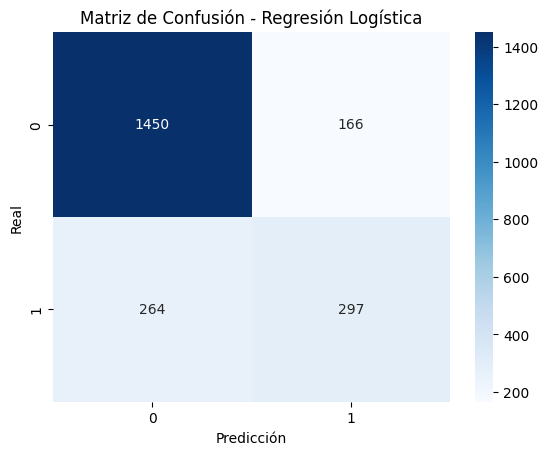

In [34]:
print("=== REGRESIÓN LOGÍSTICA ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

EVALUAR RANDOM FOREST

=== RANDOM FOREST ===
Accuracy: 0.7813504823151125
Precision: 0.6004728132387707
Recall: 0.45276292335115864
F1-score: 0.516260162601626


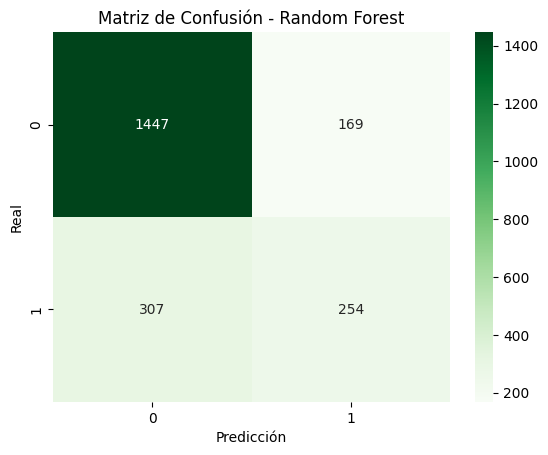

In [35]:
print("=== RANDOM FOREST ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

COMPARAR MODELOS

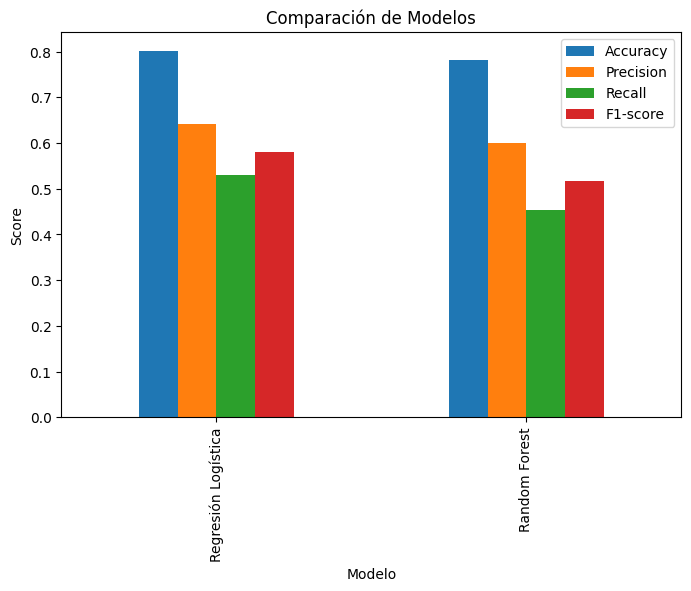

In [36]:
import pandas as pd

metrics = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

metrics.set_index("Modelo").plot(kind="bar", figsize=(8,5))

plt.title("Comparación de Modelos")
plt.ylabel("Score")

plt.show()

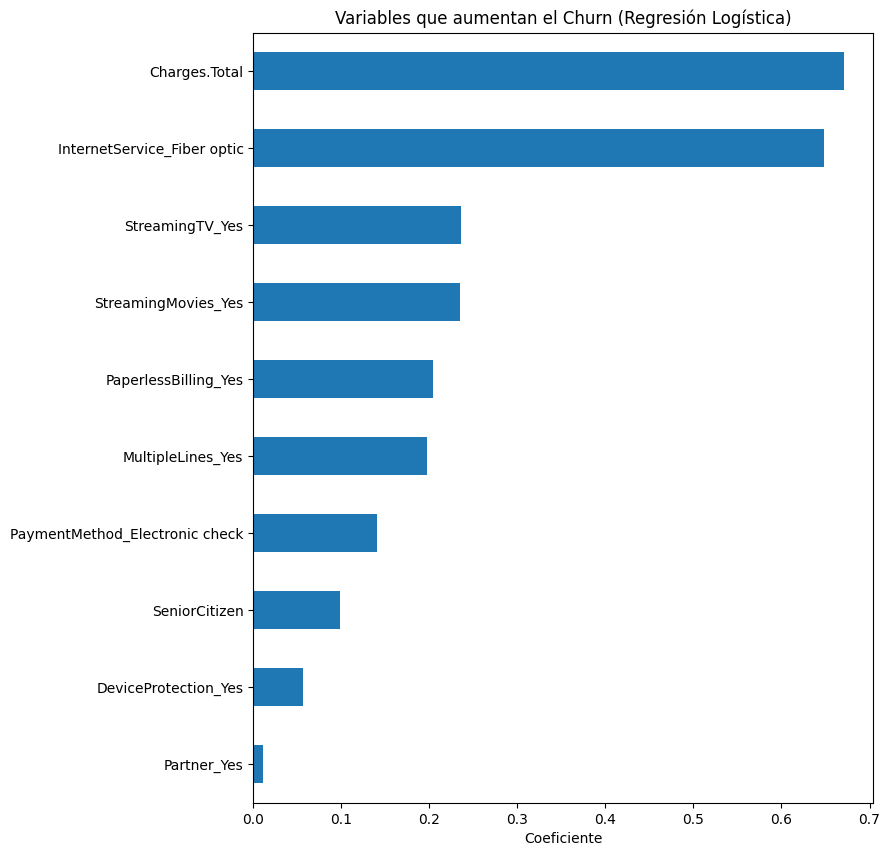

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# obtener coeficientes
coef = pd.Series(log_model.coef_[0], index=X.columns)

# ordenar
coef_sorted = coef.sort_values()

# mostrar top variables
coef_sorted.tail(10)

plt.figure(figsize=(8,10))

coef_sorted.tail(10).plot(kind="barh")

plt.title("Variables que aumentan el Churn (Regresión Logística)")
plt.xlabel("Coeficiente")

plt.show()

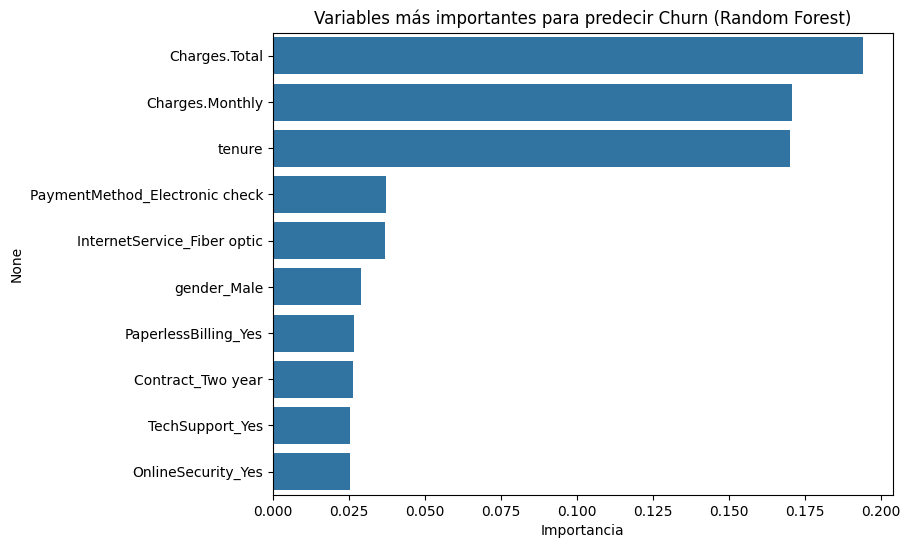

In [38]:
import pandas as pd

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importances_sorted = importances.sort_values(ascending=False)

importances_sorted.head(10)

import seaborn as sns
import matplotlib.pyplot as plt

top_features = importances_sorted.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Variables más importantes para predecir Churn (Random Forest)")
plt.xlabel("Importancia")

plt.show()

El objetivo de este análisis fue entender qué factores influyen en la cancelación de clientes en Telecom X. Para ello se realizó un proceso de exploración de datos, limpieza, visualización y construcción de modelos predictivos que permitieran identificar patrones asociados al churn.

Durante el análisis exploratorio se encontraron varios factores relevantes. Uno de los más importantes es el tipo de contrato: los clientes con contratos mensuales presentan una mayor tasa de cancelación que aquellos con contratos de uno o dos años. También se observó que el tiempo de permanencia en la empresa (tenure) influye bastante, ya que los clientes más nuevos tienden a cancelar con mayor frecuencia. Otro factor relacionado es el gasto mensual, donde los clientes con cargos más altos muestran una tendencia ligeramente mayor a cancelar. Además, variables como métodos de pago, facturación electrónica y la edad del cliente (Senior Citizen) también muestran cierta relación con el churn.

Para predecir la cancelación se utilizaron dos modelos de machine learning: Regresión Logística y Random Forest. La regresión logística requirió normalización de los datos debido a su sensibilidad a la escala de las variables, mientras que Random Forest pudo utilizar los datos directamente al estar basado en árboles de decisión. Ambos modelos fueron evaluados utilizando métricas como accuracy, precision, recall y F1-score, además de matrices de confusión para analizar su capacidad de clasificación.

El análisis de los modelos permitió identificar variables importantes para la predicción del churn, especialmente el tipo de contrato, los cargos mensuales, el tiempo de permanencia y algunos servicios asociados al plan del cliente. Estas variables ayudan a explicar gran parte del comportamiento de cancelación.

A partir de estos resultados, se pueden proponer algunas estrategias para reducir el churn. Por ejemplo, incentivar a los clientes a elegir contratos de mayor duración, implementar programas de fidelización para clientes nuevos, y analizar la estructura de precios o beneficios de los planes para mejorar la percepción de valor. Además, el uso de modelos predictivos permitiría identificar clientes con alto riesgo de cancelación y aplicar acciones preventivas antes de que abandonen el servicio.

En general, este análisis demuestra cómo el uso de datos y modelos predictivos puede ayudar a comprender mejor el comportamiento de los clientes y apoyar la toma de decisiones estratégicas para mejorar la retención.